# Paso 5 y 6: Modelado Predictivo de Zonas de Riesgo

En base a los análisis previos, hemos notado una correlación entre las zonas de mayor riesgo de inundaciones y las afectadas por sismos (así como la presencia de fracturas). 
El objetivo de este cuaderno es crear modelos de **Machine Learning** que nos permitan identificar de manera predictiva cuáles son las alcaldías o AGEBs que debemos **priorizar** para enviar ayuda a la población en escenarios de desastre.

Vamos a implementar:
1. **Agrupamiento (K-Means)** - Para perfilar grupos naturales de riesgo.
2. **Clasificación** - Para predecir si una zona debe ser de **Alta Prioridad** o no.
3. **Regresión** - Para estimar una **Puntuación Continua de Riesgo**.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos Unsupervised (K-Means)
from sklearn.cluster import KMeans

# Modelos Supervised
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import SGDClassifier # Para implementar Hinge Loss fácilmente
from sklearn.linear_model import HuberRegressor # Para Huber Loss

# Métricas de Clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score, log_loss, hinge_loss
)

# Métricas de Regresión
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos y Preparación
Simularemos la carga de los datos consolidados que ya contienen índices de riesgo de inundación, sismos, y cercanía a fracturas.

In [12]:
import os
print("Cargando y procesando datasets reales (RUSE, IMU, Atlas de Riesgo)...")

# 1. Limites AGEB 
ageb_gdf = pd.read_json('data/lmites-de-ageb-urbanas-en-la-ciudad-de-mxico.json') if False else gpd.read_file('data/lmites-de-ageb-urbanas-en-la-ciudad-de-mxico.json')
ageb_gdf['cvegeo'] = ageb_gdf['CVEGEO'].astype(str)

# 2. Fracturas (Intersectar con AGEB)
fracturas_gdf = gpd.read_file('data/Fracturas/SPC_Estructuras_Fracturas.shp')
fracturas_gdf = fracturas_gdf.to_crs(ageb_gdf.crs)
ageb_con_fracturas = gpd.sjoin(ageb_gdf, fracturas_gdf, how='inner', predicate='intersects')
ageb_gdf['tiene_fractura'] = ageb_gdf['cvegeo'].isin(ageb_con_fracturas['cvegeo']).astype(int)

# 3. RUSE (Emergencias -> Generar Target Histórico)
ruse = pd.read_csv('data/registro-unico-de-situaciones-de-emergencia.csv', low_memory=False)
ruse_limpio = ruse.dropna(subset=['latitud', 'longitud'])
geometry = [Point(xy) for xy in zip(ruse_limpio['longitud'], ruse_limpio['latitud'])]
ruse_gdf = gpd.GeoDataFrame(ruse_limpio, geometry=geometry, crs="EPSG:4326")
ageb_gdf = ageb_gdf.to_crs("EPSG:4326")

ruse_en_ageb = gpd.sjoin(ruse_gdf, ageb_gdf[['cvegeo', 'geometry']], how="inner", predicate="intersects")
target_df = ruse_en_ageb.groupby('cvegeo').size().reset_index(name='total_emergencias')

# 4. Atlas Inundaciones y Sismos
inundaciones = pd.read_csv('data/atlas-de-riesgo-inundaciones.csv')[['cvegeo', 'intensidad', 'perime_m']].copy()
inundaciones['cvegeo'] = inundaciones['cvegeo'].astype(str).str.zfill(13)
# Convertir texto a score continuo
mapper_int = {'Muy Bajo':1, 'Bajo': 2, 'Medio': 3, 'Alto': 4, 'Muy Alto': 5, 'Muy bajo':1, 'Muy alto':5}
inundaciones['inundacion_score'] = inundaciones['intensidad'].map(mapper_int).fillna(1)
in_agg = inundaciones.groupby('cvegeo').agg({'inundacion_score': 'max', 'perime_m': 'sum'}).reset_index()

sismos = pd.read_csv('data/atlas-de-riesgo-sismico.csv')[['cvegeo', 'intensidad', 'perime_m']].copy()
sismos['cvegeo'] = sismos['cvegeo'].astype(str).str.zfill(13)
sismos['sismo_score'] = sismos['intensidad'].map(mapper_int).fillna(1)
si_agg = sismos.groupby('cvegeo').agg({'sismo_score': 'max', 'perime_m': 'sum'}).reset_index()

# 5. IMU 2020 (Marginacion y Población)
imu = pd.read_csv('data/imu_2020.csv', dtype={'CVE_AGEB': str})
imu = imu[imu['NOM_ENT'] == 'Ciudad de México'][['CVE_AGEB', 'POB_TOTAL', 'IM_2020']].copy()
imu.rename(columns={'CVE_AGEB': 'cvegeo'}, inplace=True)
imu['IM_2020'] = pd.to_numeric(imu['IM_2020'], errors='coerce')
imu['POB_TOTAL'] = pd.to_numeric(imu['POB_TOTAL'], errors='coerce')

# Consolidar Dataset Final
df = ageb_gdf[['cvegeo', 'tiene_fractura', 'CVE_MUN']].copy()
df = df.merge(target_df, on='cvegeo', how='left').fillna({'total_emergencias': 0})
df = df.merge(in_agg, on='cvegeo', how='left').fillna({'inundacion_score': 0, 'perime_m': 0}).rename(columns={'perime_m': 'inundacion_perimetro'})
df = df.merge(si_agg, on='cvegeo', how='left').fillna({'sismo_score': 0, 'perime_m': 0}).rename(columns={'perime_m': 'sismo_perimetro'})
df = df.merge(imu, on='cvegeo', how='left').fillna({'IM_2020': imu['IM_2020'].median(), 'POB_TOTAL': imu['POB_TOTAL'].median()})

print(f"Dataset consolidado y sin filtraciones de datos (Data Leakage)! AGEBs totales: {len(df)}")
df.head()

Cargando y procesando datasets reales (RUSE, IMU, Atlas de Riesgo)...
Dataset consolidado y sin filtraciones de datos (Data Leakage)! AGEBs totales: 2431


,cvegeo,tiene_fractura,CVE_MUN,total_emergencias,inundacion_score,inundacion_perimetro,sismo_score,sismo_perimetro,POB_TOTAL,IM_2020
0,0901000011716,1,010,7.0,1.0,5375.088573,3.0,5375.088573,7042.0,120.133166
1,0901000012150,0,010,24.0,1.0,5978.177549,3.0,5978.177549,4588.0,123.194082
2,0901000011133,0,010,21.0,1.0,9471.504342,3.0,9471.504342,2203.0,124.883063
3,0901000011307,0,010,37.0,1.0,10168.480553,3.0,10168.480553,2914.0,125.017183
4,0901000010281,0,010,8.0,1.0,5786.473364,3.0,5786.473364,237.0,124.558595


## 2. K-Means: Descubrimiento de Clústeres de Riesgo
Utilizaremos **KMeans** para segmentar las zonas en diferentes niveles de criticidad (Ej: Baja, Media, Alta).

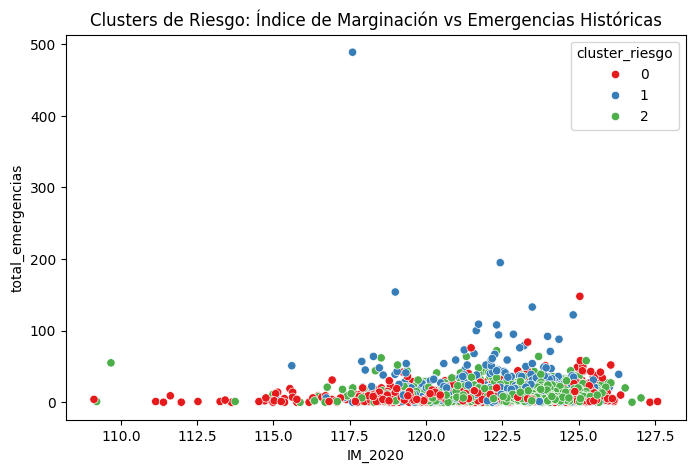

In [13]:
# Agruparemos características para identificar perfiles ambientales/sociales
features_cluster = ['inundacion_score', 'sismo_score', 'tiene_fractura', 'IM_2020', 'POB_TOTAL']
X_cluster = df[features_cluster]

# Limpiamos NaN antes de clusterizar
imputer = SimpleImputer(strategy='median')
X_cluster_imp = imputer.fit_transform(X_cluster)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_imp)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_riesgo'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,5))
sns.scatterplot(x='IM_2020', y='total_emergencias', hue='cluster_riesgo', palette='Set1', data=df)
plt.title('Clusters de Riesgo: Índice de Marginación vs Emergencias Históricas')
plt.show()

## 3. Preparación de Variables para Entrenamiento
Queremos predecir:
- **(Para Regresión)**: `Score de Riesgo Combinado` 
- **(Para Clasificación)**: `Alta Prioridad` (1 si el score de riesgo supera un umbral, 0 de lo contrario)

In [14]:
# Preparar variables para modelado supervisado
# Nuestro objetivo será predecir si una AGEB tendrá un numero de emergencias por encima del percentil 75 histórico

umbral_alta_prioridad = df['total_emergencias'].quantile(0.75)
df['alta_prioridad'] = (df['total_emergencias'] >= umbral_alta_prioridad).astype(int)

# Características
X = df[['inundacion_score', 'sismo_score', 'tiene_fractura', 'IM_2020', 'POB_TOTAL']].copy()
y_class = df['alta_prioridad']
y_reg = df['total_emergencias']

# Imputar y escalar
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.3, random_state=42)

# Aplicar imputer y scaler sobre splits
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print('Split realizado. Tamaños:', X_train.shape, X_test.shape)

Split realizado. Tamaños: (1701, 5) (730, 5)


## 4. Modelos de Clasificación
Estimaremos la necesidad de priorizar o no una zona.
Evaluaremos con: **Exactitud, Precisión, Recall, F1 Score, Cross-Entropy Loss, Hinge Loss**, 
Y como se ha solicitado expresamente: **Matriz de Confusión y Curva ROC**.

In [15]:
# Entrenamos un estimador (RandomForest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_class_train)

# Generamos predicciones y probabilidades
y_pred_class = clf.predict(X_test)
y_prob_class = clf.predict_proba(X_test)[:, 1]

# SGDClassifier con loss='hinge' para evaluar Hinge Loss (Linear SVM)
svm_clf = SGDClassifier(loss='hinge', random_state=42)
svm_clf.fit(X_train_scaled, y_class_train)
y_score_svm = svm_clf.decision_function(X_test_scaled)

# === CÁLCULO DE MÉTRICAS ===
acc = accuracy_score(y_class_test, y_pred_class)
prec = precision_score(y_class_test, y_pred_class)
rec = recall_score(y_class_test, y_pred_class)
f1 = f1_score(y_class_test, y_pred_class)
ce_loss = log_loss(y_class_test, y_prob_class)
h_loss = hinge_loss(y_class_test, y_score_svm)
roc_auc = roc_auc_score(y_class_test, y_prob_class)

print(f"--- MÉTRICAS DE CLASIFICACIÓN ---")
print(f"Accuracy (Exactitud): {acc:.4f}")
print(f"Precision (Precisión): {prec:.4f}")
print(f"Recall (Sensibilidad): {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Cross-Entropy Loss (Log Loss): {ce_loss:.4f}")
print(f"Hinge Loss (Vía SGD): {h_loss:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

--- MÉTRICAS DE CLASIFICACIÓN ---
Accuracy (Exactitud): 0.7767
Precision (Precisión): 0.6259
Recall (Sensibilidad): 0.4394
F1 Score: 0.5163
Cross-Entropy Loss (Log Loss): 0.6471
Hinge Loss (Vía SGD): 0.6249
AUC-ROC: 0.7199


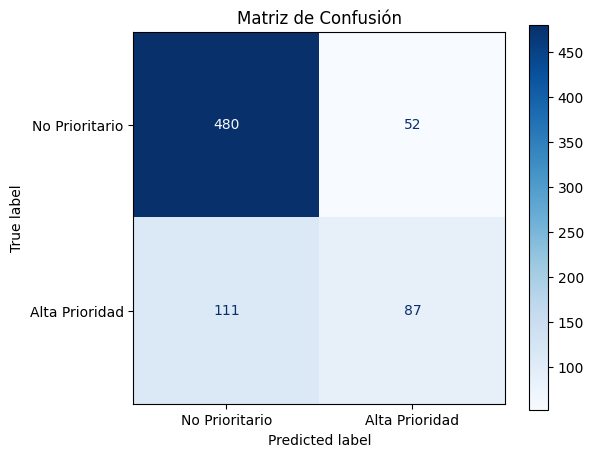

In [16]:
# === MATRIZ DE CONFUSIÓN ===
cm = confusion_matrix(y_class_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Prioritario', 'Alta Prioridad'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title("Matriz de Confusión")
plt.show()

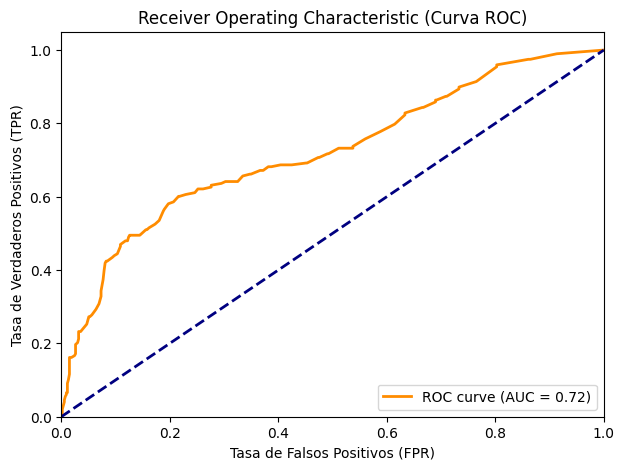

In [17]:
# === CURVA ROC ===
fpr, tpr, thresholds = roc_curve(y_class_test, y_prob_class)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Receiver Operating Characteristic (Curva ROC)')
plt.legend(loc="lower right")
plt.show()

## 5. Modelos de Regresión
Predeciremos el `Score de Riesgo` numérico para las zonas.

In [18]:
# Entrenamos el modelo de Regresión
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_reg_train)
y_pred_reg = reg.predict(X_test)

# Para Huber Loss podemos entrenar un estimador especializado
huber = HuberRegressor()
huber.fit(X_train_scaled, y_reg_train)
y_pred_huber = huber.predict(X_test_scaled)

# === MÉTICAS DE REGRESIÓN ===
mae = mean_absolute_error(y_reg_test, y_pred_reg)
mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

# Scikit-Learn no expone Huber loss directo como función métrica simple para evaluar 
# otras predicciones (como en RandomForest) pero evaluaremos el dataset con la penalidad Huber estándar.
def huber_loss_calc(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * (error ** 2)
    linear_loss = delta * np.abs(error) - 0.5 * (delta ** 2)
    return np.where(is_small_error, squared_loss, linear_loss).mean()

huber_l = huber_loss_calc(y_reg_test, y_pred_reg, delta=1.0)

print("--- MÉTRICAS DE REGRESIÓN (Random Forest) ---")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"R2:   {r2:.4f}")
print(f"Huber Loss (delta=1): {huber_l:.4f}")

--- MÉTRICAS DE REGRESIÓN (Random Forest) ---
MAE:  8.3362
MSE:  292.5961
RMSE: 17.1054
MAPE: 1290613901070342.7500
R2:   -0.4795
Huber Loss (delta=1): 7.8560
